In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as colors

We will then read in the data using `pd.read_csv` and then view the data description using the `describe()` method. 

In [7]:
#df = pd.read_csv("data/experimental_data/latent_vectors_by_group.csv")
#df = pd.read_csv("data/experimental_data/gratin_results_for_n2_+myoIb_1_trackedPar.csv")
df = pd.read_csv("../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results.csv")
                 

In [8]:
df.describe()

,Unnamed: 0,p_fBM,p_LW,p_sBM,p_OU,p_CTRW,alpha,length,U_1,U_2,...,h_8,h_9,h_10,h_11,h_12,h_13,h_14,h_15,h_16,n
count,12320.000000,1.232000e+04,1.232000e+04,1.232000e+04,1.232000e+04,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,...,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000
mean,14735.740179,2.549241e-01,2.829992e-02,2.301115e-01,3.392270e-01,0.147437,0.902931,10.292127,-2.893662,-2.404649,...,-0.934715,0.423772,0.736394,-0.155909,-0.264281,-0.075644,-0.304502,0.315680,0.540560,14735.740179
std,8380.288858,1.479581e-01,8.932438e-02,1.453053e-01,1.918636e-01,0.309277,0.285669,6.083167,3.458255,3.320127,...,0.935366,1.401240,1.150349,0.963728,1.717218,0.673462,0.974670,1.474824,0.785864,8380.288858
min,0.000000,2.405457e-10,3.812443e-13,5.102970e-10,2.717159e-11,0.000007,0.176651,7.000000,-9.879051,-9.549088,...,-4.021444,-6.133990,-5.357845,-2.763761,-7.235849,-2.118829,-2.582959,-1.979577,-3.397144,0.000000
25%,7458.750000,1.833735e-01,3.583582e-04,1.253624e-01,2.196086e-01,0.000784,0.680722,7.000000,-5.774701,-4.782527,...,-1.332186,0.127390,0.521195,-0.806854,-0.596588,-0.565570,-0.904756,-0.539113,0.185819,7458.750000
50%,14783.000000,2.522946e-01,1.779894e-03,2.208527e-01,3.515502e-01,0.004218,0.890542,9.000000,-3.219336,-2.849489,...,-0.884406,0.696298,1.017194,-0.251859,0.224474,-0.086790,-0.451950,-0.070717,0.663906,14783.000000
75%,21979.250000,3.214826e-01,1.101929e-02,3.238174e-01,4.723959e-01,0.056583,1.108867,11.000000,-0.481474,-0.662187,...,-0.342801,1.200880,1.433465,0.404252,0.813334,0.389639,0.091673,0.556159,1.041281,21979.250000
max,29410.000000,9.932374e-01,9.801654e-01,9.276725e-01,8.982344e-01,1.000000,1.780221,225.000000,5.653491,6.976326,...,1.677575,3.450146,2.709752,3.220301,2.157242,2.698936,5.447537,5.730943,2.688317,29410.000000


As it is quite a big table, we can view the columns by calling upon `df.columns`.

In [ ]:
df.columns

to take a copy of the dataframe with only the useful/desired columns

In [ ]:
workingdf = df[["n", "L", "U_1", "U_2", "alpha", "best_model", "x", "y","log_D", "D","n_points","traj_ID"]].copy()

In [9]:
workingdf = df

## Column Remapping / Renaming

Create a dictionnary to make plotting easier later on

In [10]:
simple_model_numbers = {'CTRW': 1,
                 'LW': 2,
                 'fBM': 3,
                 'sBM': 4,
                 'OU': 5}

To create new columns in our dataframe, we start with defining the column name `workingdf['new_column_name']` and then we assign the mapped values using the `.map()` method.

In [11]:
workingdf['model_id'] = workingdf['best_model'].map(simple_model_numbers)

When we view the dataframe, we can see that we now have our new column at the end.

In [12]:
workingdf

,Unnamed: 0,best_model,p_fBM,p_LW,p_sBM,p_OU,p_CTRW,alpha,length,U_1,...,h_11,h_12,h_13,h_14,h_15,h_16,n,on_axon,on_synapse,model_id
0,0.0,OU,0.187767,3.889881e-04,0.188887,6.215908e-01,0.001367,1.008025,14,-4.754628,...,-0.762746,-0.308827,-0.421474,-0.926361,-0.324057,1.058333,0.0,True,False,5
1,1.0,OU,0.260578,3.111114e-02,0.174414,4.085880e-01,0.125308,0.636722,13,-5.499941,...,-0.022064,0.422501,0.704927,-0.155969,-0.272804,0.803180,1.0,True,False,5
2,9.0,CTRW,0.000010,3.443894e-09,0.000105,5.873685e-07,0.999885,0.543163,7,3.243089,...,2.386129,-5.422728,0.047638,2.514988,4.847704,-1.310006,9.0,True,True,1
3,10.0,OU,0.313659,2.636713e-03,0.175968,5.075063e-01,0.000229,0.813046,9,-6.042993,...,-1.151046,1.205440,-0.391143,-1.084688,-0.910592,1.043948,10.0,True,False,5
4,14.0,OU,0.223642,1.694074e-04,0.178615,5.965227e-01,0.001051,0.903163,10,-5.437588,...,-0.642715,0.202438,-0.173602,-1.244463,-0.129971,0.961252,14.0,True,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12315,29401.0,CTRW,0.090739,1.432204e-03,0.115948,1.197480e-01,0.672133,0.729258,10,1.056888,...,0.470609,-0.974300,0.839581,0.074910,1.251366,-0.218807,29401.0,True,False,1
12316,29405.0,OU,0.244453,2.638062e-02,0.187031,5.416511e-01,0.000484,0.907698,7,-4.207875,...,-1.448983,1.024430,-0.511412,-0.714556,-1.239084,1.475376,29405.0,True,True,5
12317,29408.0,CTRW,0.000165,3.760257e-08,0.012504,3.064765e-04,0.987024,0.751854,9,3.610639,...,1.059844,-4.551107,-0.192921,0.485577,4.020660,0.771880,29408.0,True,True,1
12318,29409.0,OU,0.347595,7.084039e-02,0.204715,3.760662e-01,0.000783,0.883023,7,-5.456406,...,-1.141121,1.483583,-0.466130,-0.715811,-1.023668,1.176877,29409.0,True,False,5


## Visualising the Data

As there is already a best_model column with this data, we can take a quick look to see how the data is distributed across each best_model.

To do this we can use Seaborn's `FacetGrid` method to plot individual density-neutron crossplots (scatterplots) for each model. 

The FacetGrid is used to create an underlying structure for the plot. In this example, the FacetGrid has been passed the dataframe we are working with (`workingdf`), the column we want to split the plots up by (`col`)

We can then map a density neutron crossplot ontop of that `FacetGrid`.

In [ ]:
g = sns.FacetGrid(workingdf, col='best_model',sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x= 'x', y= 'y')
g.set(xlim=(-10, 50))
g.set(ylim=(-25, 150))
g.set_titles(col_template='Best model : {col_name}')

z = sns.FacetGrid(workingdf, col='best_model',sharex=False, sharey=False)
z.map_dataframe(sns.scatterplot, x= 'U_1', y= 'U_2')
z.set(xlim=(-10, 10))
z.set(ylim=(-10, 10))
z.set_titles(col_template='Best model : {col_name}')


In [ ]:
u = sns.FacetGrid(workingdf, col='best_model',sharex=False, sharey=False)
u.map_dataframe(sns.histplot, 'log_D')
u.set(xlim=(-3,3))
u.set(ylim=(0,200))
u.set_titles(col_template='Best model : {col_name}')

In [ ]:
u = sns.FacetGrid(workingdf, col='best_model',sharex=False, sharey=False)
u.map_dataframe(sns.histplot, 'D')
u.set(xlim=(0,10))
u.set(ylim=(0,200))
u.set_titles(col_template='Best model : {col_name}')

## Analizing data within the latent space



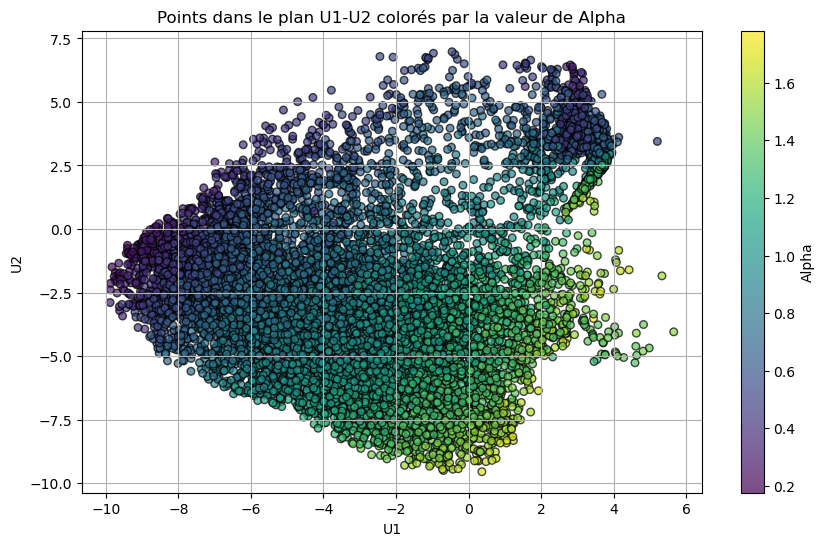

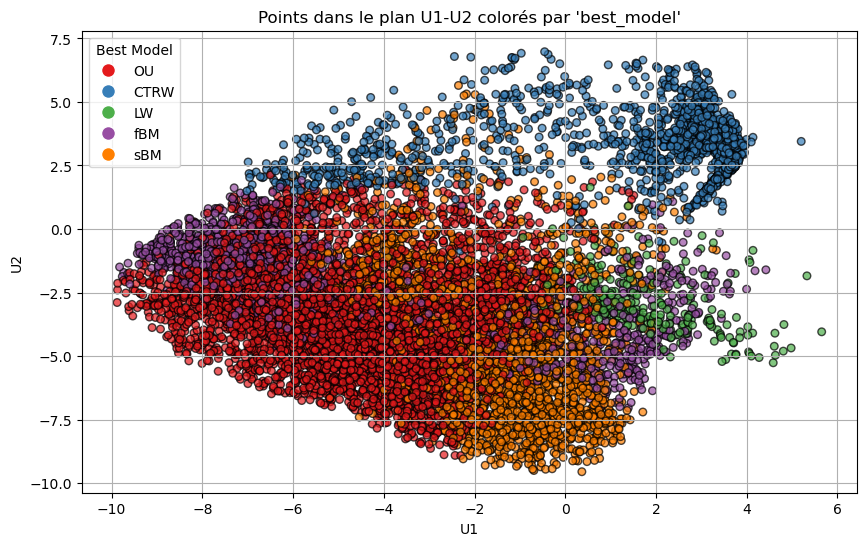

In [20]:
# Charger le fichier CSV
def load_data(file_path):
    return pd.read_csv(file_path)

# Fonction pour tracer les points colorés par alpha
def plot_by_alpha(data):
    U1 = data['U_1']
    U2 = data['U_2']
    alpha = data['alpha']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=alpha, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='Alpha')
    plt.title("Points dans le plan U1-U2 colorés par la valeur de Alpha")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

# Fonction pour tracer les points colorés par best_model
def plot_by_best_model(data):
    U1 = data['U_1']
    U2 = data['U_2']
    unique_models = data['best_model'].unique()
    colors = {model: color for model, color in zip(unique_models, plt.cm.Set1.colors)}

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=data['best_model'].map(colors), s=30, edgecolor='k', alpha=0.7)

    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=model) 
                     for model, color in colors.items()]

    plt.legend(handles=legend_labels, title="Best Model")
    plt.title("Points dans le plan U1-U2 colorés par 'best_model'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

#fonction pour tracer selon densité
def plot_by_density(data):
    U1 = data['U_1']
    U2 = data['U_2']
    alpha = data['D']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=alpha, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='Density')
    plt.title("Points dans le plan U1-U2 colorés par 'D'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

#fonction pour tracer selon nb points
def plot_by_n_points(data):
    U1 = data['U_1']
    U2 = data['U_2']
    alpha = data['n_points']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=alpha, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='Alpha')
    plt.title("Points dans le plan U1-U2 colorés par 'n_points'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

#fonction pour tracer selon nb points
def plot_by_log_D(data):
    U1 = data['U_1']
    U2 = data['U_2']
    alpha = data['log_D']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=alpha, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='log_D')
    plt.title("Points dans le plan U1-U2 colorés par 'log_D'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()


# Exemple d'utilisation
#file_path = "../../data/experimental_data/gratin_results_for_tracktor_film9.csv"
file_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results.csv"

data = load_data(file_path)

# Appeler chaque fonction pour visualiser
plot_by_alpha(data)       # Tracer les points par alpha
plot_by_best_model(data)  # Tracer les points par best_model
#plot_by_density(data)
#plot_by_n_points(data)
#plot_by_log_D(data)



Before we plot any data we need to create a few functions. The first is a create plot function, which will take a number of arguments and our facies curve, and will generate a conventional log plot.

In [ ]:
def create_plot(wellname, dataframe, curves_to_plot, depth_curve, log_curves=[], model_curves=[]):
    # Count the number of tracks we need
    num_tracks = len(curves_to_plot)
    
    model_color = ['#F4D03F', '#F5B041','#DC7633','#6E2C00', '#1B4F72','#2E86C1', '#AED6F1', '#A569BD', '#196F3D', 'red','black', 'blue']
    
            
    # Setup the figure and axes
    fig, ax = plt.subplots(nrows=1, ncols=num_tracks, figsize=(num_tracks*2, 10))
    
    # Create a super title for the entire plot
    fig.suptitle(wellname, fontsize=20, y=1.05)
    
    # Loop through each curve in curves_to_plot and create a track with that data
    for i, curve in enumerate(curves_to_plot):
        if curve in model_curves:
            cmap_facies = colors.ListedColormap(model_color[0:dataframe[curve].max()], 'indexed')
            
            cluster=np.repeat(np.expand_dims(dataframe[curve].values,1), 100, 1)
            im=ax[i].imshow(cluster, interpolation='none', cmap=cmap_facies, aspect='auto',vmin=dataframe[curve].min(),vmax=dataframe[curve].max(), extent=[0,20, depth_curve.max(), depth_curve.min()])
        else:
            ax[i].plot(dataframe[curve], depth_curve)

        
        # Setup a few plot cosmetics
        ax[i].set_title(curve, fontsize=14, fontweight='bold')
        ax[i].grid(which='major', color='lightgrey', linestyle='-')
        
        # We want to pass in the deepest depth first, so we are displaying the data 
        # from shallow to deep
        ax[i].set_ylim(depth_curve.max(), depth_curve.min())
#         ax[i].set_ylim(3500, 3000)

        # Only set the y-label for the first track. Hide it for the rest
        if i == 0:
            ax[i].set_ylabel('DEPTH (m)', fontsize=18, fontweight='bold')
        else:
            plt.setp(ax[i].get_yticklabels(), visible = False)
        
        # Check to see if we have any logarithmic scaled curves
        if curve in log_curves:
            ax[i].set_xscale('log')
            ax[i].grid(which='minor', color='lightgrey', linestyle='-')
        

    
    plt.tight_layout()
    plt.show()
    
    return cmap_facies


### Splitting Data by Well Function
The second method we will create will be used to split up our dataframe by wells. This is done using the `groupby` function, and will allow us to store each dataframe within a list for easy access later.

In [ ]:
"""def well_splitter(dataframe, groupby_column):
    grouped = dataframe.groupby(groupby_column)
    
    # Create empty lists
    wells_as_dfs = []
    wells_wellnames = []

    #Split up the data by well
    for well, data in grouped:
        wells_as_dfs.append(data)
        wells_wellnames.append(well)

    print('index  wellname')
    for i, name in enumerate(wells_wellnames):
        print(f'{i}      {name}')
    
    return wells_as_dfs, wells_wellnames"""

In [ ]:
#grouped_wells, grouped_names = well_splitter(workingdf, 'WELL')

We now have a list of wells and their index position with the list object. 

## Clustering - Unsupervised

In this section, we are going to setup our clustering models and run them on our dataset.

First we will import our clustering models from the sklearn library.

In [16]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

### Finding the Optimum Number of Clusters

To make sure that K-Means and Gaussian Mixture Modelling models are working efficiently we need to provide them with a starting number of clusters. If the number of clusters is incorrectly selected, the algorithms may not perform well or could take longer to resolve (especially if the number is too high).

We can attempt to identify the optimum number of clusters using an elbow plot, where the goal is to select a number for the clusters based on the 'elbow' or inflection formed in the results. There are other methods such as the silhouette method for picking the number of clusters.

For this example, we will use the elbow plot. To do this we evaluate the model performance over a given range of clusters, and then from the plot identify the most suitable number.

In [6]:
def optimise_k_means(data, max_k):
    means = []
    inertias = []
    
    for k in range(1,max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
        
    fig = plt.subplots(figsize=(10, 5))
    plt.plot(means, inertias, 'o-')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()


For clustering to work, we need to remove any missing values. This is achieved using the `dropna()` function.

In [13]:
import pandas as pd
workingdf=load_data(file_path)
workingdf.dropna(inplace=True)

We can then use the `describe()` function to make sure our data is still good after the missing data values have been removed.

In [14]:
workingdf.describe()

,Unnamed: 0,p_fBM,p_LW,p_sBM,p_OU,p_CTRW,alpha,length,U_1,U_2,...,h_8,h_9,h_10,h_11,h_12,h_13,h_14,h_15,h_16,n
count,12320.000000,1.232000e+04,1.232000e+04,1.232000e+04,1.232000e+04,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,...,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000,12320.000000
mean,14735.740179,2.549241e-01,2.829992e-02,2.301115e-01,3.392270e-01,0.147437,0.902931,10.292127,-2.893662,-2.404649,...,-0.934715,0.423772,0.736394,-0.155909,-0.264281,-0.075644,-0.304502,0.315680,0.540560,14735.740179
std,8380.288858,1.479581e-01,8.932438e-02,1.453053e-01,1.918636e-01,0.309277,0.285669,6.083167,3.458255,3.320127,...,0.935366,1.401240,1.150349,0.963728,1.717218,0.673462,0.974670,1.474824,0.785864,8380.288858
min,0.000000,2.405457e-10,3.812443e-13,5.102970e-10,2.717159e-11,0.000007,0.176651,7.000000,-9.879051,-9.549088,...,-4.021444,-6.133990,-5.357845,-2.763761,-7.235849,-2.118829,-2.582959,-1.979577,-3.397144,0.000000
25%,7458.750000,1.833735e-01,3.583582e-04,1.253624e-01,2.196086e-01,0.000784,0.680722,7.000000,-5.774701,-4.782527,...,-1.332186,0.127390,0.521195,-0.806854,-0.596588,-0.565570,-0.904756,-0.539113,0.185819,7458.750000
50%,14783.000000,2.522946e-01,1.779894e-03,2.208527e-01,3.515502e-01,0.004218,0.890542,9.000000,-3.219336,-2.849489,...,-0.884406,0.696298,1.017194,-0.251859,0.224474,-0.086790,-0.451950,-0.070717,0.663906,14783.000000
75%,21979.250000,3.214826e-01,1.101929e-02,3.238174e-01,4.723959e-01,0.056583,1.108867,11.000000,-0.481474,-0.662187,...,-0.342801,1.200880,1.433465,0.404252,0.813334,0.389639,0.091673,0.556159,1.041281,21979.250000
max,29410.000000,9.932374e-01,9.801654e-01,9.276725e-01,8.982344e-01,1.000000,1.780221,225.000000,5.653491,6.976326,...,1.677575,3.450146,2.709752,3.220301,2.157242,2.698936,5.447537,5.730943,2.688317,29410.000000


To keep our model simple we will work with 2 columns u_1 et u_2 but we could have used more.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

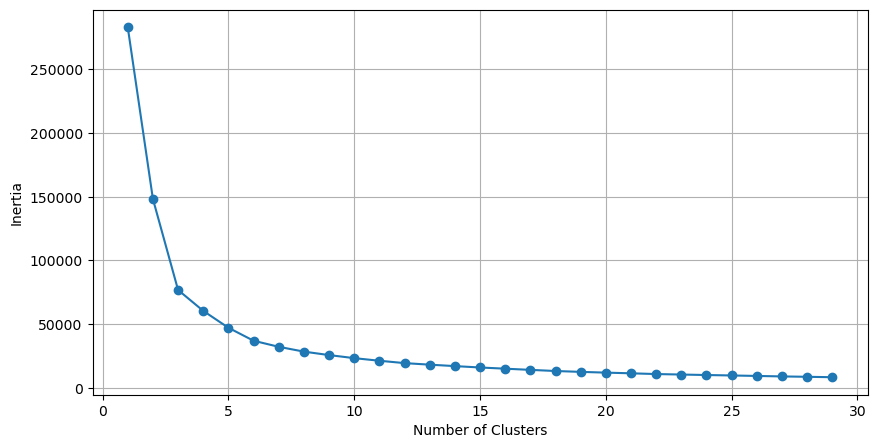

In [17]:
optimise_k_means(workingdf[[ 'U_1', 'U_2']],30)

In the plot above, we can see that the inertia (sum of the squared distances to the nearest cluster center) decreases as we increase the number of clusters. There is no clear defined break within this dataset, however, we can see that the slope changes from about 3 clusters onwards. 

### Fitting the Clustering Models

In [18]:
# Create the KMeans model with the selected number of clusters
kmeans = KMeans(n_clusters=3)

# Fit the model to our dataset
kmeans.fit(workingdf[['U_1', 'U_2']])

# Assign the data back to the workingdf
workingdf['KMeans'] = kmeans.labels_

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Plotting the Results

Now that the clusters have been computed using KMeans method, we can plot the data to see how well the predicted in relation to the labelled models. Note that this methods is unsupervised and do not use the labelled data for training. 


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


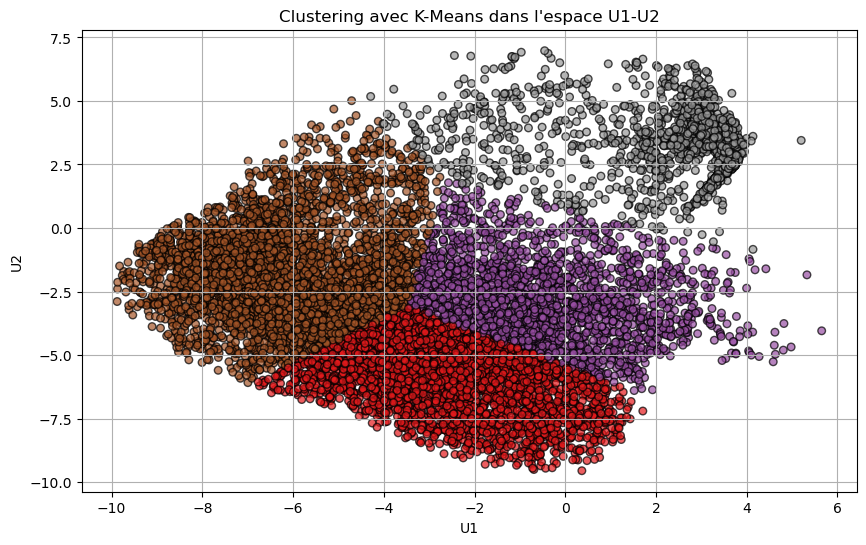

In [22]:
# Charger le fichier CSV
def load_data(file_path):
    return pd.read_csv(file_path)

# Fonction pour afficher des clusters et ellipses
def plot_clusters(data, n_clusters=4):
    U1 = data['U_1']
    U2 = data['U_2']

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(data[['U_1', 'U_2']])

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=clusters, cmap='Set1', s=30, edgecolor='k', alpha=0.7)

    plt.title("Clustering avec K-Means dans l'espace U1-U2")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

# Exemple d'utilisation
#file_path = "../../data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv"
file_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results.csv"
data = load_data(file_path)

plot_clusters(data)

#file_path_16D = r'data/experimental_data/gratin_results_for_n2_+myoIb_1_trackedPar.csv'

#newdata = load_data(file_path_16D)

#plot_clusters(newdata)  # Tracer les clusters

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(


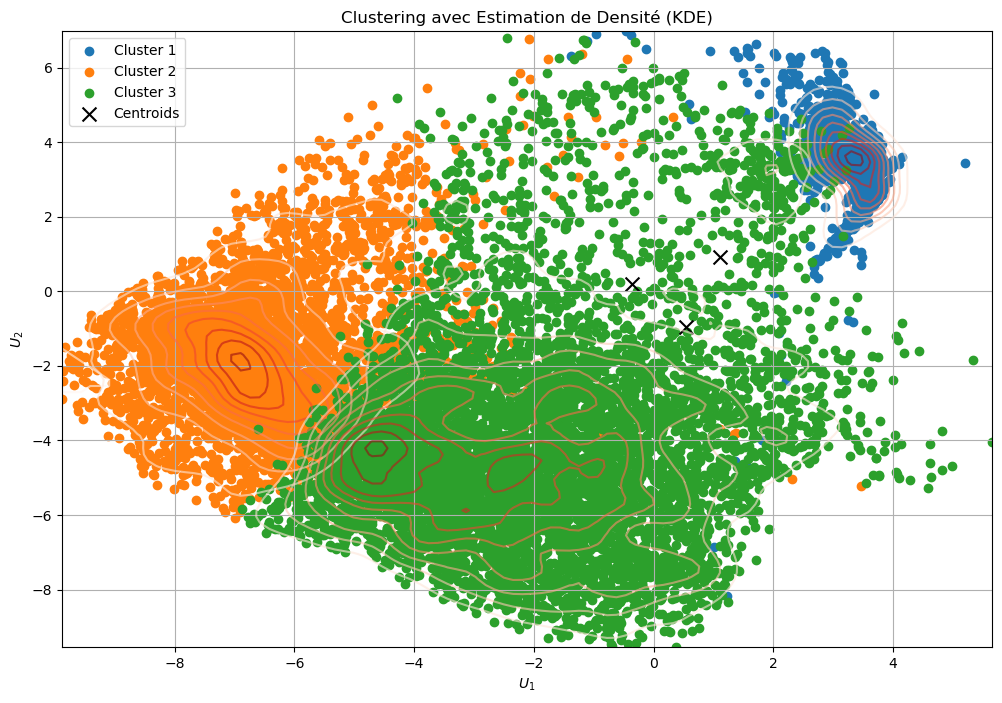

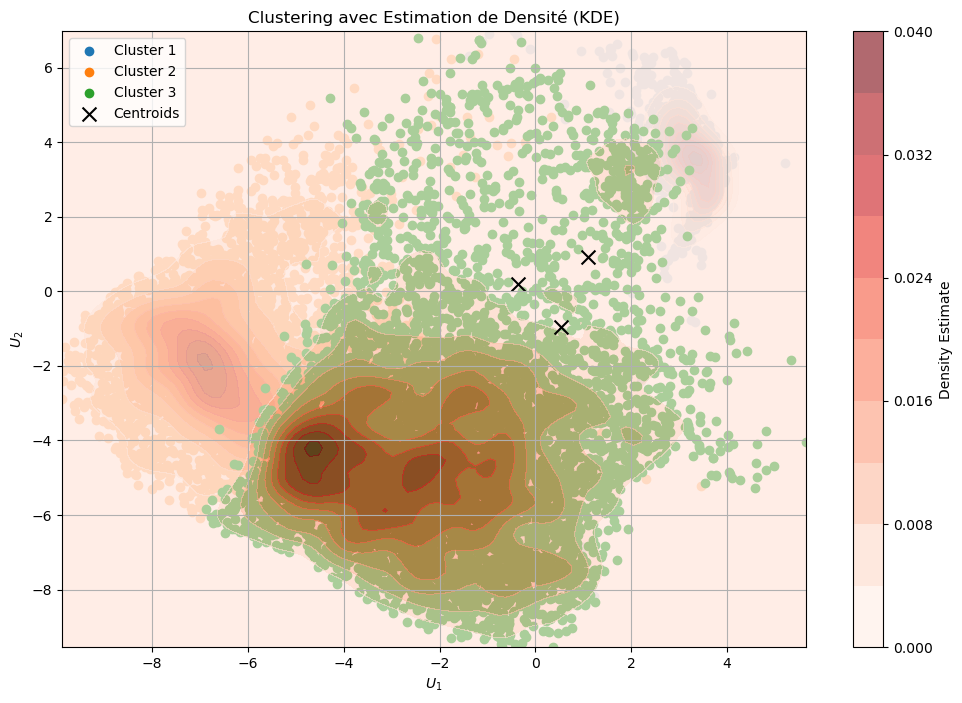

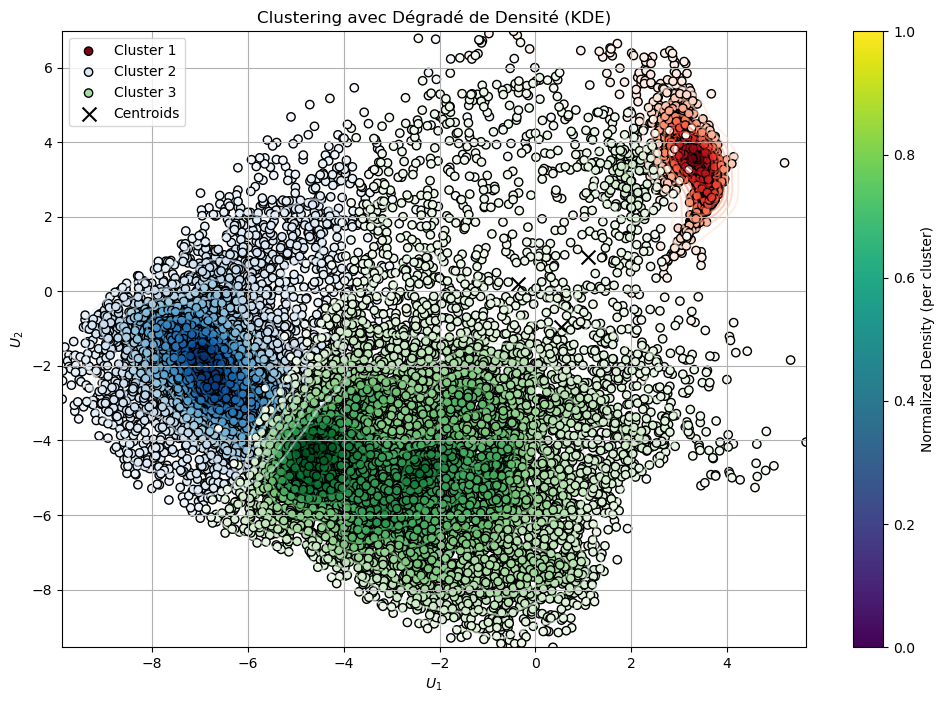

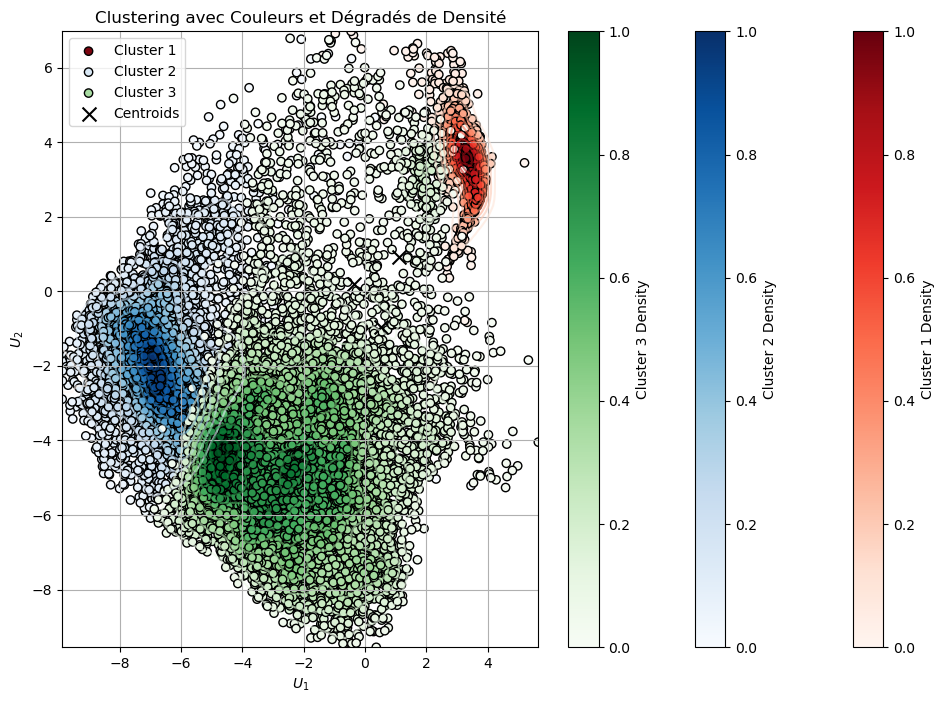

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
import pandas as pd

# Charger les fichiers pour examiner leur structure

#file1_path = "../../data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv"
file1_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results.csv"
#file1_path = "../../data/experimental_data/gratin_results_for_0deb5656cadde25b.csv"
#file2_path = r'data/experimental_data/n2_+myoIb_1_trackedPar.csv'

# Chargement des fichiers CSV
data = pd.read_csv(file1_path)
#data2 = pd.read_csv(file2_path)
# Paramètres
n_clusters = 3  # Nombre de clusters (modifiable)

# Extraction des colonnes U_1 et U_2
u1_u2 = data[['U_1', 'U_2']].dropna()

# Étape 1: Clustering avec K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#labels = kmeans.fit_predict(u1_u2)
labels = kmeans.fit_predict(data[['h_1','h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16']])


# Étape 2: Estimation de la densité pour chaque cluster
densities = []
grid_size = 100
x_min, x_max = u1_u2['U_1'].min(), u1_u2['U_1'].max()
y_min, y_max = u1_u2['U_2'].min(), u1_u2['U_2'].max()
x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, grid_size),
    np.linspace(y_min, y_max, grid_size)
)
grid_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

for cluster in range(n_clusters):
    cluster_points = u1_u2[labels == cluster]
    kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
    log_density = kde.score_samples(grid_points)
    densities.append(np.exp(log_density).reshape(grid_size, grid_size))

# Étape 3: Visualisation des clusters et densités
plt.figure(figsize=(12, 8))
for cluster in range(n_clusters):
    cluster_points = u1_u2[labels == cluster]
    plt.scatter(
        cluster_points['U_1'], cluster_points['U_2'], label=f"Cluster {cluster + 1}"
    )
    plt.contour(
        x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap="Reds"
    )

# Ajouter les centres de clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids', s=100)

plt.title('Clustering avec Estimation de Densité (KDE)')
plt.xlabel('$U_1$')
plt.ylabel('$U_2$')
plt.legend()
plt.grid(True)
plt.show()

# Réinitialisation de la figure pour inclure la légende des densités
plt.figure(figsize=(12, 8))
for cluster in range(n_clusters):
    cluster_points = u1_u2[labels == cluster]
    plt.scatter(
        cluster_points['U_1'], cluster_points['U_2'], label=f"Cluster {cluster + 1}"
    )
    contour = plt.contourf(
        x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap="Reds"
    )

# Ajouter une barre de couleur pour représenter les densités
cbar = plt.colorbar(contour, label="Density Estimate")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids', s=100)

plt.title('Clustering avec Estimation de Densité (KDE)')
plt.xlabel('$U_1$')
plt.ylabel('$U_2$')
plt.legend()
plt.grid(True)
plt.show()

# Nouvelle figure avec dégradé de couleur selon la densité
plt.figure(figsize=(12, 8))
color_maps = ['Reds', 'Blues', 'Greens','Purples','Oranges']  # Palettes pour chaque cluster

for cluster in range(n_clusters):
    cluster_points = u1_u2[labels == cluster].values
    kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
    log_density = kde.score_samples(cluster_points)
    density = np.exp(log_density)
    
    # Normaliser les densités pour le cluster (0 à 1 pour correspondre à la palette)
    density_norm = (density - density.min()) / (density.max() - density.min())
    
    # Afficher les points avec un dégradé selon la densité
    plt.scatter(
        cluster_points[:, 0], cluster_points[:, 1],
        c=density_norm, cmap=color_maps[cluster], label=f"Cluster {cluster + 1}", edgecolor='k'
    )
    
    # Dessiner les contours de densité
    plt.contour(
        x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap=color_maps[cluster]
    )

# Ajouter les centres des clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids', s=100)

# Ajouter une légende des clusters
plt.colorbar(label="Normalized Density (per cluster)")
plt.title('Clustering avec Dégradé de Densité (KDE)')
plt.xlabel('$U_1$')
plt.ylabel('$U_2$')
plt.legend()
plt.grid(True)
plt.show()


# Nouvelle figure avec des couleurs différentes pour chaque cluster et dégradé interne
plt.figure(figsize=(12, 8))
color_maps = ['Reds', 'Blues', 'Greens','Purples','Oranges']  # Couleurs pour chaque cluster

for cluster in range(n_clusters):
    cluster_points = u1_u2[labels == cluster].values
    kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
    log_density = kde.score_samples(cluster_points)
    density = np.exp(log_density)
    
    # Normaliser les densités pour le cluster (0 à 1 pour correspondre à la palette)
    density_norm = (density - density.min()) / (density.max() - density.min())
    
    # Afficher les points avec un dégradé selon la densité
    scatter = plt.scatter(
        cluster_points[:, 0], cluster_points[:, 1],
        c=density_norm, cmap=color_maps[cluster], label=f"Cluster {cluster + 1}", edgecolor='k'
    )
    
    # Ajouter une barre de couleur pour chaque cluster
    cbar = plt.colorbar(scatter, label=f"Cluster {cluster + 1} Density")
    
    # Dessiner les contours de densité
    plt.contour(
        x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap=color_maps[cluster]
    )

# Ajouter les centres des clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='x', label='Centroids', s=100)

# Ajuster les titres et légendes
plt.title('Clustering avec Couleurs et Dégradés de Densité')
plt.xlabel('$U_1$')
plt.ylabel('$U_2$')
plt.legend()
plt.grid(True)
plt.show()

## Clustering directly in the 16D latent space

In [36]:
#dfl = pd.read_csv("data/experimental_data/gratin_results_for_0deb5656cadde25b.csv")
dfl= pd.read_csv("../../../../psc-gnn-rw/data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv")
#dfl=pd.read_csv("../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results 2.csv")

print(dfl.columns)

workingdfl=dfl

print(workingdfl)

Index(['Unnamed: 0', 'best_model', 'p_fBM', 'p_LW', 'p_sBM', 'p_OU', 'p_CTRW',
       'alpha', 'length', 'U_1', 'U_2', 'h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16', 'n'],
      dtype='object')
      Unnamed: 0 best_model     p_fBM          p_LW     p_sBM      p_OU  \
0              0        fBM  0.907967  2.323474e-05  0.062440  0.029568   
1              1        fBM  0.805085  9.551836e-07  0.081759  0.113143   
2              2        fBM  0.797234  1.053537e-05  0.186094  0.016652   
3              3        fBM  0.839258  3.389466e-06  0.151898  0.008826   
4              4        fBM  0.760893  1.083149e-05  0.182666  0.056429   
...          ...        ...       ...           ...       ...       ...   
3995        3995        fBM  0.959957  6.513138e-05  0.035590  0.004388   
3996        3996        fBM  0.801257  3.325161e-05  0.164880  0.033828   
3997        3997        fBM  0.890606  5.3845

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

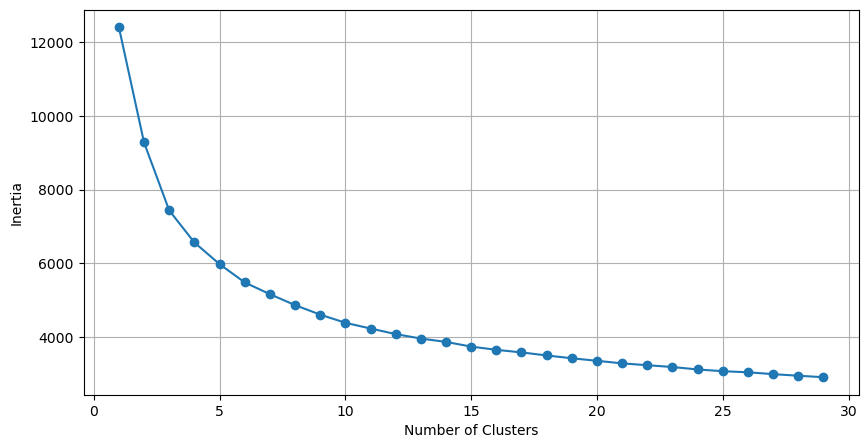

In [40]:
#Find the number of high dimensional clusters
optimise_k_means(workingdfl[[ 'h_1', 'h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16']], 30)


In [38]:
# Create the KMeans model with the selected number of clusters
kmeans = KMeans(n_clusters=4)

# Fit the model to our dataset
kmeans.fit(workingdfl[['h_1', 'h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16']])

# Assign the data back to the workingdf
workingdfl['KMeans'] = kmeans.labels_

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


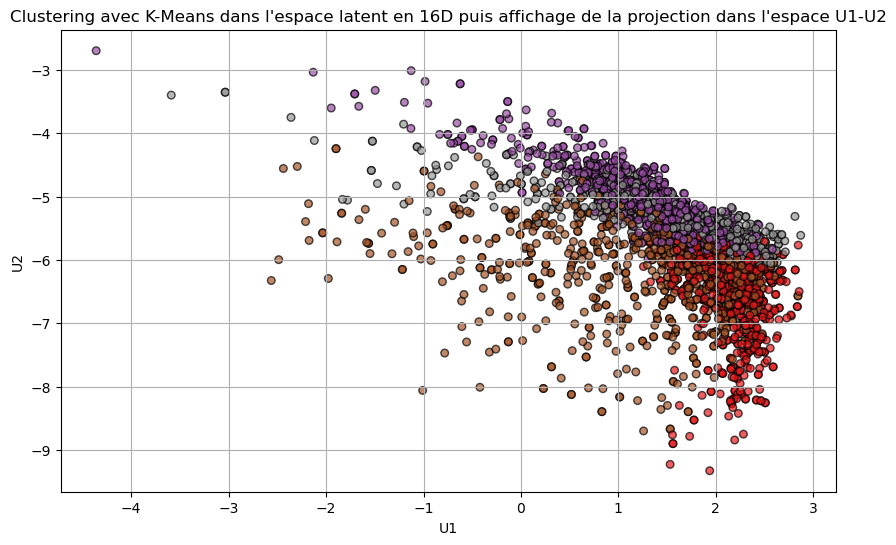

In [41]:
# Fonction pour afficher en 2D grâce à Umap des clusters obtenus après l'analyse en 16D
def plot_clusters_from_16D_in_2D(data, n_clusters=4):
    U1 = data['U_1']
    U2 = data['U_2']

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(data[['h_1', 'h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16']])

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=clusters, cmap='Set1', s=30, edgecolor='k', alpha=0.7)

    plt.title("Clustering avec K-Means dans l'espace latent en 16D puis affichage de la projection dans l'espace U1-U2")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

#file_path_16D = r'data/experimental_data/gratin_results_for_n2_+myoIb_1_trackedPar.csv'
file_path_16D = r"../../../../psc-gnn-rw/data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv"
#file_path_16D = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results 2.csv"
newdata = load_data(file_path_16D)    

plot_clusters_from_16D_in_2D(newdata)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/var/folders/6_/wjb9ddn965xckzzthm1x7rnr0000gn/T/ipykernel_26069/2089418103.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cluster_colors = plt.cm.get_cmap('tab10', n_clusters)


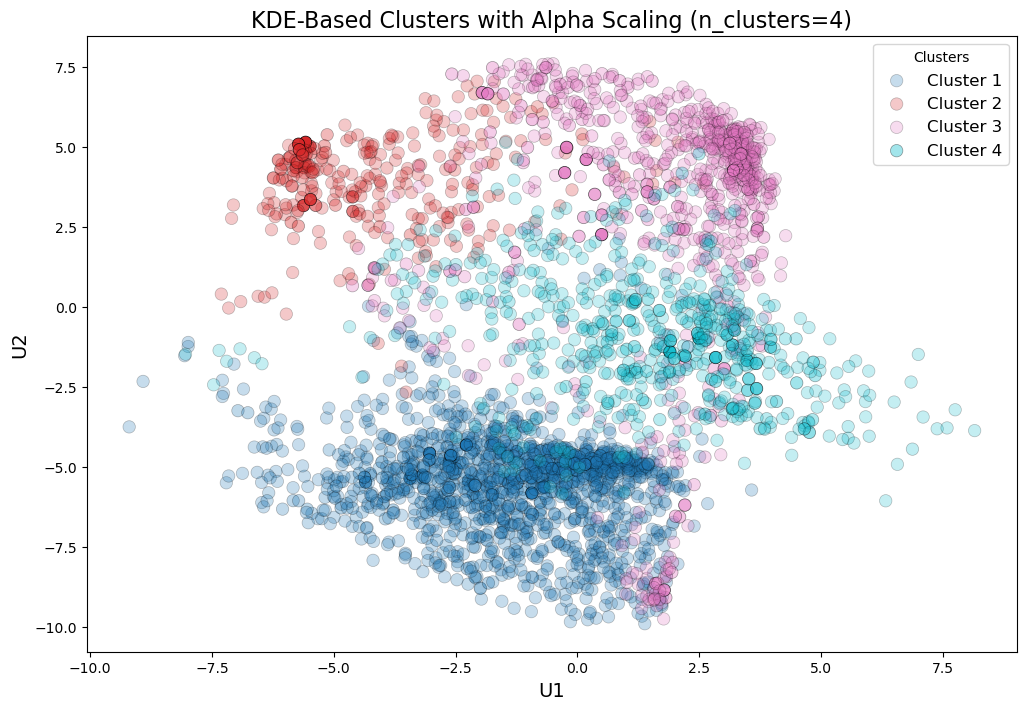

In [46]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Function to load data (placeholder for your actual data loader)
def load_data(file_path):
    return pd.read_csv(file_path)

# Function to plot clusters with KDE and adjusted alpha scaling
def plot_16D_kde_clusters(data, n_clusters=5, bandwidth=0.5, point_size=60):
    # Extract the 16D features and 2D projection data
    features_16D = data[['h_1', 'h_2', 'h_3', 'h_4', 'h_5', 'h_6', 'h_7', 'h_8',
                          'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14', 'h_15', 'h_16']]
    U1 = data['U_1']
    U2 = data['U_2']
    
    # Perform K-Means clustering on the 16D space
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(features_16D)
    
    # Create a color map for clusters
    cluster_colors = plt.cm.get_cmap('tab10', n_clusters)

    # Initialize the plot
    plt.figure(figsize=(12, 8))
    plt.title(f"KDE-Based Clusters with Alpha Scaling (n_clusters={n_clusters})", fontsize=16)
    plt.xlabel("U1", fontsize=14)
    plt.ylabel("U2", fontsize=14)
    
    # Loop through each cluster to compute KDE and plot
    for cluster_idx in range(n_clusters):
        # Get points belonging to the current cluster
        cluster_points = features_16D[clusters == cluster_idx]
        cluster_U1 = U1[clusters == cluster_idx]
        cluster_U2 = U2[clusters == cluster_idx]
        
        # Compute KDE for the cluster in 16D
        kde = gaussian_kde(cluster_points.T, bw_method=bandwidth)
        cluster_density = kde(cluster_points.T)  # Density values for each point
        
        # Normalize density for alpha scaling (0.25 to 1)
        norm = Normalize(vmin=cluster_density.min(), vmax=cluster_density.max())
        alpha_values = 0.25 + 0.75 * norm(cluster_density)  # Scale to [0.25, 1]
        
        # Plot each point with intensity based on its density
        plt.scatter(cluster_U1, cluster_U2, c=[cluster_colors(cluster_idx)] * len(cluster_U1),
                    alpha=alpha_values, s=point_size, edgecolor='k', linewidth=0.5,
                    label=f"Cluster {cluster_idx + 1}")

    # Add legend and grid
    plt.legend(title="Clusters", loc='best', fontsize=12)
    plt.grid(False)
    plt.show()

# File path to your data
file_path_16D = r'../../../../psc-gnn-rw/data/experimental_data/gratin_results_for_n2_+myoIb_1_trackedPar.csv'
#file_path_16D = r"../../../../psc-gnn-rw/data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv"


# Load the data
newdata = load_data(file_path_16D)

# Plot the KDE with clusters
plot_16D_kde_clusters(newdata, n_clusters=4, bandwidth=0.5, point_size=80)

## DBSCAN

Clustering DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
Étapes de l'algorithme :
Identifier les points noyaux :
Un point est un noyau si au moins \text{min_samples} points se trouvent à une distance eps ou moins de lui.

Étendre un cluster :
Si un noyau est trouvé, tous les points dans son rayon 
eps deviennent partie du cluster.
Ce processus est répété pour les noyaux adjacents jusqu'à ce qu'aucun nouveau point ne puisse être ajouté.

Marquer le bruit :
Les points qui ne font partie d'aucun cluster sont marqués comme du bruit (Cluster=−1).

on peut évaluer deux paramètres:
efs (plus eps est grand, plus les clusters seront larges, mais il peut regrouper des points peu liés.
Une valeur trop petite peut isoler des points qui devraient être dans un cluster) 

min samples (nombre minimum de points requis pour qu'un point soit considéré comme un noyau. 
Grand min samples => détection de clusters très denses uniquement. Valeur classique = nb dim + 1, à ajuster selon les résultats graphiques et le contexte global)


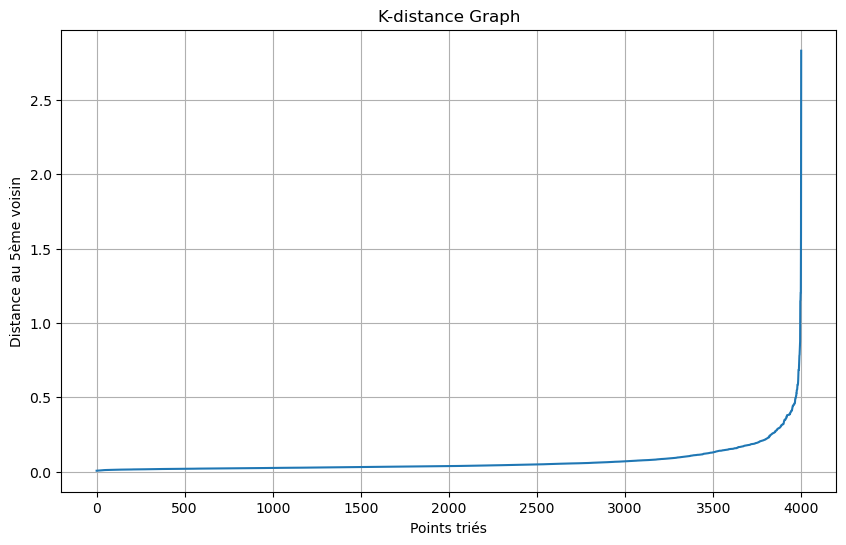

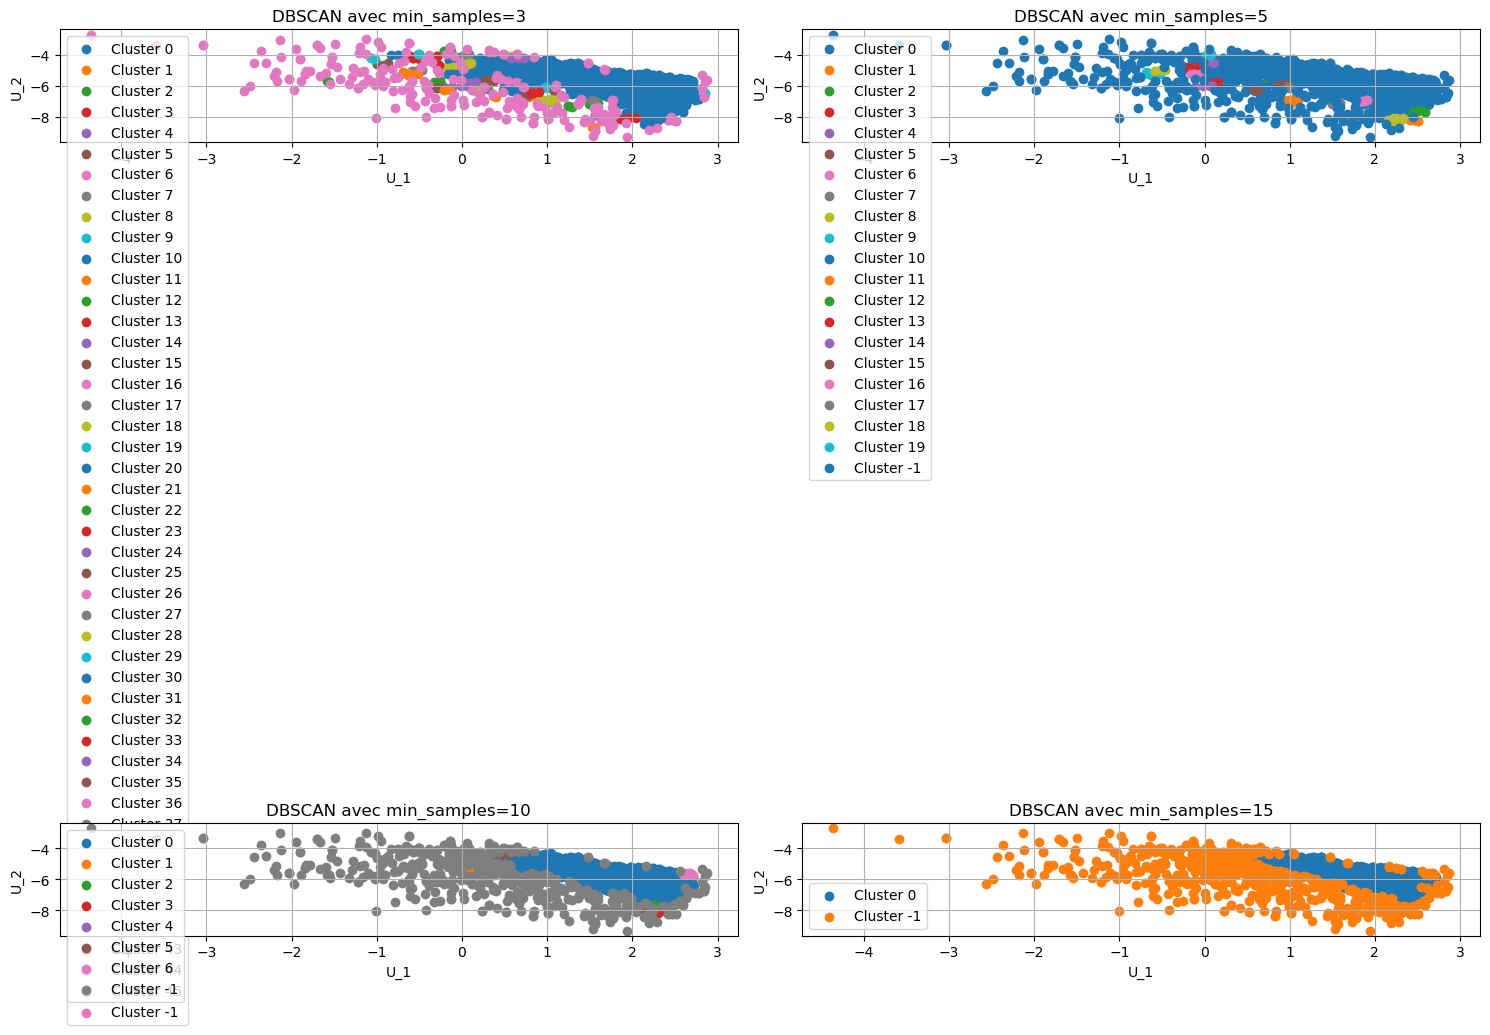

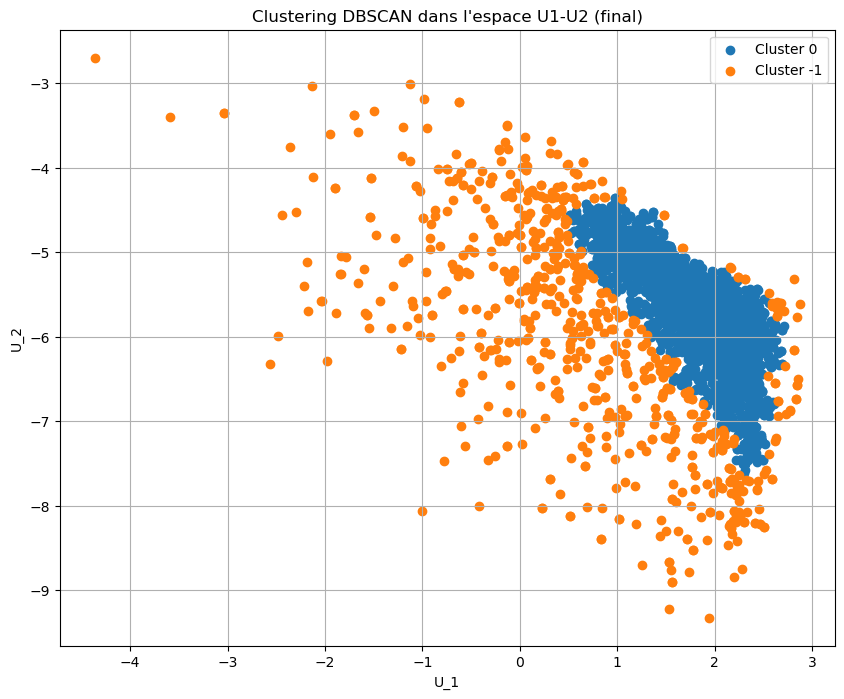

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Charger les données
#file_path = "data/experimental_data/gratin_results_for_0deb5656cadde25b.csv"
file_path = r"../../../../psc-gnn-rw/data/generated_data/gratin_results_for_combined_brownian_motion_walks.csv"
#file_path="../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results 2.csv"

data = pd.read_csv(file_path)

# Extraction des colonnes U_1 et U_2
u1_u2 = data[['U_1', 'U_2']].dropna()

# Normalisation des données
scaler = StandardScaler()
u1_u2_scaled = scaler.fit_transform(u1_u2)

# Visualisation des distances pour choisir eps
nearest_neighbors = NearestNeighbors(n_neighbors=5)
neighbors = nearest_neighbors.fit(u1_u2_scaled)
distances, indices = neighbors.kneighbors(u1_u2_scaled)

# Trier les distances pour visualiser le genou
sorted_distances = np.sort(distances[:, -1])
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('K-distance Graph')
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.grid()
plt.show()

# Exploration des valeurs de min_samples et affichage des clusters
min_samples_values = [3, 5, 10, 15]
plt.figure(figsize=(15, 10))
for i, min_samples in enumerate(min_samples_values, 1):
    dbscan = DBSCAN(eps=0.14, min_samples=min_samples)
    clusters = dbscan.fit_predict(u1_u2_scaled)
    
    plt.subplot(2, 2, i)
    for cluster in set(clusters):
        cluster_points = u1_u2[clusters == cluster]
        plt.scatter(cluster_points['U_1'], cluster_points['U_2'], label=f'Cluster {cluster}')
    
    plt.title(f'DBSCAN avec min_samples={min_samples}')
    plt.xlabel('U_1')
    plt.ylabel('U_2')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

# Application finale de DBSCAN avec les paramètres choisis
dbscan = DBSCAN(eps=0.14, min_samples=15)
clusters = dbscan.fit_predict(u1_u2_scaled)

# Ajout des étiquettes de clusters au DataFrame
u1_u2['Cluster'] = clusters

# Affichage graphique des clusters finaux
plt.figure(figsize=(10, 8))
for cluster in set(clusters):
    cluster_points = u1_u2[u1_u2['Cluster'] == cluster]
    plt.scatter(cluster_points['U_1'], cluster_points['U_2'], label=f'Cluster {cluster}')

plt.title('Clustering DBSCAN dans l\'espace U1-U2 (final)')
plt.xlabel('U_1')
plt.ylabel('U_2')
plt.legend()
plt.grid()
plt.show()

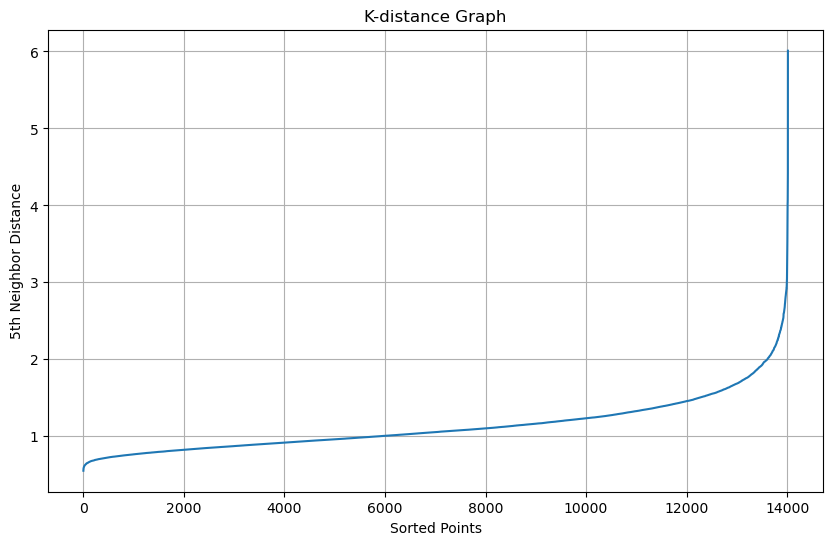

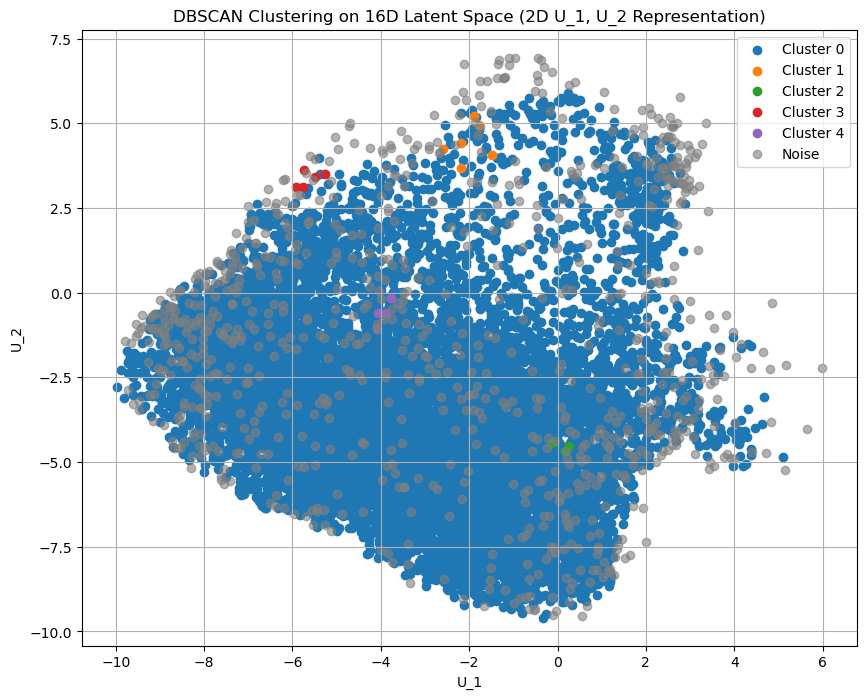

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np 

# Load the data
file_path = "../../../../psc-gnn-rw/data/experimental_data/gratin_results_for_0deb5656cadde25b.csv"
#file_path_16D = r"../../../../psc-gnn-rw/data/generated_data/processed_trajectories.csv"

data = pd.read_csv(file_path)

# Extract 16D latent features
latent_features = data[['h_1', 'h_2', 'h_3', 'h_4', 'h_5', 'h_6', 'h_7', 'h_8',
                        'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14', 'h_15', 'h_16']].dropna()

# Normalize the 16D latent space
scaler = StandardScaler()
features_scaled = scaler.fit_transform(latent_features)

# Compute the K-Distance graph to determine the optimal `eps`
nearest_neighbors = NearestNeighbors(n_neighbors=10)
neighbors = nearest_neighbors.fit(features_scaled)
distances, indices = neighbors.kneighbors(features_scaled)

# Sort distances (10th nearest neighbor) and plot the K-distance graph
sorted_distances = np.sort(distances[:, -1])

# Plot the K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('K-distance Graph')
plt.xlabel('Sorted Points')
plt.ylabel('5th Neighbor Distance')
plt.grid()
plt.show()

# Manually select the optimal `eps` by inspecting the graph
# You can change this value based on the "elbow" or knee of the curve in the plot above
optimal_eps = 1.3  # Replace this with your chosen value based on the graph

# Apply DBSCAN with manually selected `eps`
dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
clusters = dbscan.fit_predict(features_scaled)

# Add the cluster labels to the original DataFrame
data['Cluster'] = clusters

# Extract U_1 and U_2 for visualization (assuming U_1 and U_2 exist in the DataFrame)
u1_u2 = data[['U_1', 'U_2']].dropna()  # Ensure that U_1 and U_2 are present in the data

# Plot the clusters in the 2D U_1, U_2 space
plt.figure(figsize=(10, 8))
unique_clusters = set(clusters)

for cluster in unique_clusters:
    cluster_points = u1_u2[data['Cluster'] == cluster]  # Filter the points based on the cluster label
    if cluster == -1:  # Noise points
        plt.scatter(cluster_points['U_1'], cluster_points['U_2'], c='gray', alpha=0.6, label='Noise')
    else:
        plt.scatter(cluster_points['U_1'], cluster_points['U_2'], label=f'Cluster {cluster}')

plt.title('DBSCAN Clustering on 16D Latent Space (2D U_1, U_2 Representation)')
plt.xlabel('U_1')
plt.ylabel('U_2')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# Charger les fichiers
#results_path = "../../data/experimental_data/gratin_results_for_0deb5656cadde25b.csv"
#locs_path = "../../data/experimental_data/0deb5656cadde25b.locs"
#results_path = "../../data/experimental_data/gratin_results_for_processed_segmented_trajectories.csv"
#locs_path = "../../data/experimental_data/processed_segmented_trajectories.csv"
#locs_path = "../../data/experimental_data/0deb5656cadde25b_segmented_trajectories.csv"
#results_path = "../../data/experimental_data/gratin_results_for_0deb5656cadde25b_segmented_trajectories.csv"
locs_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_trajectories.csv"
results_path = "../../../../psc-gnn-rw/data/experimental_data/gratin_results_for_0deb5656cadde25b_segmented_trajectories 2.csv"

# Lire les fichiers CSV
gratin_results = pd.read_csv(results_path)
locs_data = pd.read_csv(locs_path)

# Conserver uniquement les colonnes utiles de locs_data
locs_subset = locs_data[['n', 'on_axon', 'on_synapse']]

# Supprimer les doublons pour éviter les erreurs lors de la jointure
locs_subset = locs_subset.drop_duplicates(subset='n')

# Effectuer la jointure sur la colonne 'n'
merged_data = gratin_results.merge(locs_subset, on='n', how='left')

# Renommer les colonnes pour plus de clarté
#merged_data.rename(columns={'on_axon': 'on_axon', 'on_synapse': 'on_synapse'}, inplace=True)

# Sauvegarder le fichier CSV résultant
output_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results 2.csv"
merged_data.to_csv(output_path, index=False)

print(f"Le fichier mis à jour a été sauvegardé sous '{output_path}'")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
#file_path = "../../data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results.csv"
file_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b_segmented_updated_gratin_results 2.csv"
df = pd.read_csv(file_path)

# Définir une couleur pour chaque combinaison de is_axon et is_synapse
def assign_color(row):
    if row['on_axon'] and row['on_synapse']:
        return 'purple'  # Les deux actifs
    elif row['on_axon']:
        return 'red'  # Seulement is_axon
    elif row['on_synapse']:
        return 'blue'  # Seulement is_synapse
    else:
        return 'gray'  # Aucun actif

# Appliquer les couleurs
df['color'] = df.apply(assign_color, axis=1)

# Tracé du nuage de points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['U_1'], y=df['U_2'], hue=df['color'], palette={'red': 'red', 'blue': 'blue', 'purple': 'purple', 'gray': 'gray'}, legend=False)

# Création de la légende personnalisée
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='red', label='Axon'),
    mpatches.Patch(color='blue', label='Synapse'),
    mpatches.Patch(color='purple', label='Les deux'),
    mpatches.Patch(color='gray', label='Aucun')
]
plt.legend(handles=legend_patches, title="Type")

plt.xlabel("U1")
plt.ylabel("U2")
plt.title("Représentation des trajectoires dans l'espace U1-U2")

In [ ]:
"""import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os



def process_files(input_files, output_file):
    # Initialiser un DataFrame vide pour fusionner les données
    combined_df = pd.DataFrame()

    for input_file in input_files:
        # Lire le fichier CSV
        df = pd.read_csv(input_file)

        # Sélectionner les colonnes nécessaires
        columns_to_keep = [
            "n","x","y","frame","t",
            "on_synapse", "on_axon"
        ]
        df = df[columns_to_keep]

        # Conserver les doublons et fusionner avec le DataFrame combiné
        combined_df = pd.concat([combined_df, df])

    # Trier par la colonne 'n', puis par 'on_axon' et 'on_synapse'
    combined_df = combined_df.sort_values(by=["n", "on_axon", "on_synapse"])

    # Sauvegarder dans un fichier CSV de sortie
    combined_df.to_csv("../../data/experimental_data/"+output_file, index=False)

input_files = ["../../data/experimental_data/0deb5656cadde25b.locs"]
    # Ajouter les chemins des autres fichiers ici
output_file = r"processed_segmented_trajectories.csv"

process_files(input_files, output_file)
print(f"Fichiers traités et sauvegardés dans : {output_file}")"""

In [ ]:
import pandas as pd    

# Load the dataset
file_path = "../../../../psc-gnn-rw/data/experimental_data/0deb5656cadde25b.locs"  

def segment_trajectories_between_axon_and_synapse(file_path):
    df=pd.read_csv(file_path)
    #new_data = df.sort_values(by=["n","frame"])
    #print(new_data.head(n=20))
    new_df = pd.DataFrame(columns=df.columns)
    cpt_traj = 0
    for n in range(int(df['n'].max()) + 1):
    #for n in range(10000):
        selected_rows = df[df['n'] == n]
        selected_rows=selected_rows.reset_index(drop=True)
        if len(selected_rows)>50:
            #print(selected_rows)
            #print(selected_rows.loc[0])
            selected_rows.at[0, 'n'] = cpt_traj
            #print(n,cpt_traj)
            new_df = pd.concat([new_df, selected_rows.iloc[[0]]], ignore_index=True)
            s=selected_rows.loc[0]['on_synapse']
            a=selected_rows.loc[0]['on_axon']
            j=1
            while j < len(selected_rows):
                while j < len(selected_rows) and selected_rows.loc[j, 'on_synapse'] == s and selected_rows.loc[j, 'on_axon'] == a:
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    j+=1
                cpt_traj+=1
                if j < len(selected_rows):
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    s=selected_rows.loc[j]['on_synapse']
                    a=selected_rows.loc[j]['on_axon']
                    j+=1
    print(new_df.head(n=20))
    return new_df
                    
            
new_data = segment_trajectories_between_axon_and_synapse(file_path)          
output_path = file_path.split('.locs')[0]+"_segmented_trajectories.csv"
new_data.to_csv(output_path)#, index=False)
print(output_path)

# Display a preview
#print(new_data.head())


In [ ]:
"""import pandas as pd   

# Load the dataset
file_path = "../../data/experimental_data/0deb5656cadde25b.locs"  

def segment_trajectories_between_axon_and_synapse(file_path):
    df = pd.read_csv(file_path)
    
    df['n'] = pd.to_numeric(df['n'], errors='coerce')

    new_df = pd.DataFrame(columns=df.columns)
    cpt_traj = 0

    for n in range(int(df['n'].max()) + 1):  
        selected_rows = df[df['n'] == n].reset_index(drop=True)

        if len(selected_rows) > 5:
            #print(selected_rows)
            #print(selected_rows.loc[0])
            print(n)

            selected_rows.at[0, 'n'] = cpt_traj
            new_df = pd.concat([new_df, selected_rows.iloc[[0]]], ignore_index=True)

            s = selected_rows.loc[0, 'on_synapse']
            a = selected_rows.loc[0, 'on_axon']
            j = 1

            while j < len(selected_rows):
                while j < len(selected_rows) and selected_rows.loc[j, 'on_synapse'] == s and selected_rows.loc[j, 'on_axon'] == a:
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    j += 1
                cpt_traj += 1
                if j < len(selected_rows):
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    s = selected_rows.loc[j, 'on_synapse']
                    a = selected_rows.loc[j, 'on_axon']
                    j += 1

    print(new_df.head(20))
    return new_df

new_data = segment_trajectories_between_axon_and_synapse(file_path)
output_path = "modified_trajectories.csv"
new_data.to_csv(output_path, index=False)  # Ensure index is not written"""


In [ ]:
df = pd.read_csv(file_path)
n=7
df[df['n'] == n].reset_index(drop=True)